In [23]:
import sys
import os
root_path = os.path.abspath(os.path.join(os.getcwd(), '..'))
if root_path not in sys.path:
    sys.path.append(root_path)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
--- 최종 배송 기간(20일 기준)에 따른 출고 소요 시간 비교 ---
   is_over_20days      mean    median         max  count
0           False  2.841711  2.111921   23.481146  96754
1            True  6.352314  3.896331  125.775521  14051


NameError: name 'dpi' is not defined

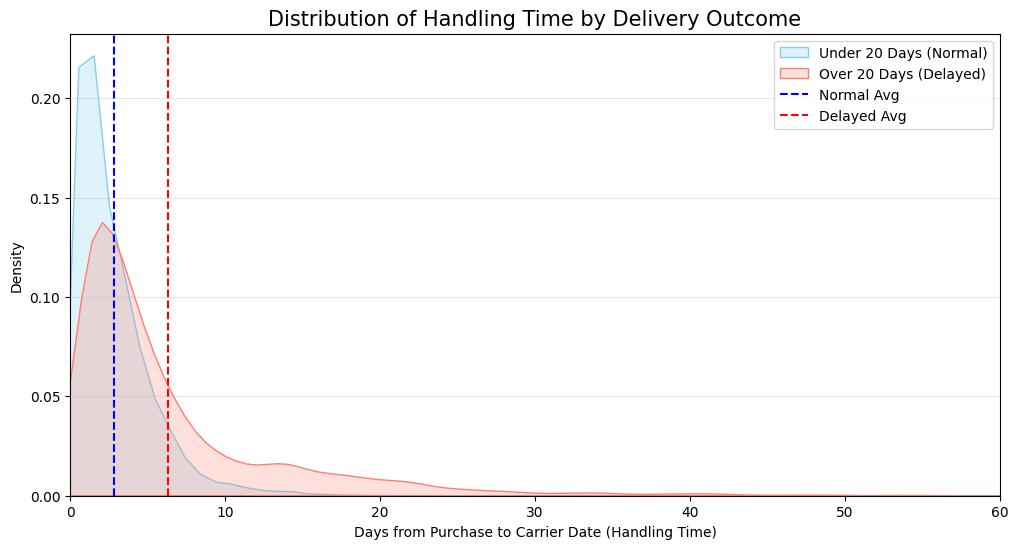

In [25]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import precision_score, recall_score, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import os
from src.utils.helpers import save_figure
from src.utils.helpers import load_and_cast_final_df

root_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
data_path = os.path.join(root_path, "data","final")
path = os.path.join(data_path, "final_df.csv")

final_df = load_and_cast_final_df(path).copy()

# Handling Time 계산: 주문 시점부터 물류사 인도 시점까지 (일 단위)
# 소수점까지 계산하여 정확한 분포를 확인합니다.
final_df['handling_time'] = (final_df['order_delivered_carrier_date'] - final_df['order_purchase_timestamp']).dt.total_seconds() / (24 * 3600)
final_df['is_over_20days'] = final_df['total_day'] == '20day+'
# 20일 이상 배송 여부에 따른 Handling Time 평균 비교
handling_analysis = final_df.groupby('is_over_20days')['handling_time'].agg(['mean', 'median', 'max', 'count']).reset_index()

print("--- 최종 배송 기간(20일 기준)에 따른 출고 소요 시간 비교 ---")
print(handling_analysis)

plt.figure(figsize=(12, 6))

# 데이터 분포 시각화
sns.kdeplot(data=final_df[final_df['is_over_20days'] == False], x='handling_time', label='Under 20 Days (Normal)', fill=True, color='skyblue')
sns.kdeplot(data=final_df[final_df['is_over_20days'] == True], x='handling_time', label='Over 20 Days (Delayed)', fill=True, color='salmon')

# 평균선 표시
plt.axvline(final_df[final_df['is_over_20days'] == False]['handling_time'].mean(), color='blue', linestyle='--', label='Normal Avg')
plt.axvline(final_df[final_df['is_over_20days'] == True]['handling_time'].mean(), color='red', linestyle='--', label='Delayed Avg')

plt.title('Distribution of Handling Time by Delivery Outcome', fontsize=15)
plt.xlabel('Days from Purchase to Carrier Date (Handling Time)')
plt.ylabel('Density')
plt.xlim(0, 60) # 15일 이후는 극소수이므로 가독성을 위해 제한
plt.legend()
plt.grid(axis='y', alpha=0.3)

save_figure("배송기간에 따른 출고 소요시간.png")

plt.show()


###########################################################

# 1. 알람 기준 설정 (예: 주문 후 4일 이내에 출고 안 되면 알람)
threshold_days = 6

# 2. 알람 발생 유무 판별 (Alarm Group vs No Alarm Group)
# carrier_date가 주문일로부터 threshold_days보다 늦게 찍혔거나, 아직 안 찍힌 경우를 가정
final_df['alarm_raised'] = final_df['handling_time'] >= threshold_days

# 3. 실제 결과(is_over_20days)와 알람(alarm_raised) 비교 분석
# Confusion Matrix 계산
# 실제(True)가 행, 예측(Alarm)이 열
cm = confusion_matrix(final_df['is_over_20days'], final_df['alarm_raised'])
tn, fp, fn, tp = cm.ravel()

# 4. 결과 출력
print(f"--- [알람 기준: {threshold_days}일 이상 소요 시] 예측 정확도 분석 ---")
print(f"1. 정밀도 (Precision): {tp/(tp+fp):.2%}") # 알람이 울린 것 중 실제로 20일 넘게 걸린 비율
print(f"2. 재현율 (Recall): {tp/(tp+fn):.2%}")    # 실제로 20일 넘게 걸린 것 중 알람이 울린 비율
print(f"3. 전체 정확도 (Accuracy): {accuracy_score(final_df['is_over_20days'], final_df['alarm_raised']):.2%}")


###########################################################


final_df['route'] = final_df['seller_state'] + " -> " + final_df['customer_state']
final_df['handling_time'] = (final_df['order_delivered_carrier_date'] - final_df['order_purchase_timestamp']).dt.total_seconds() / (24 * 3600)
final_df['pure_transit_time'] = (final_df['order_delivered_customer_date'] - final_df['order_delivered_carrier_date']).dt.total_seconds() / (24 * 3600)

# 2. 경로별 동적 임계값 산출 로직
route_transit_avg = final_df.groupby('route')['handling_time'].mean()
global_transit_avg = final_df['pure_transit_time'].mean()

def get_dynamic_threshold(route):
    avg_transit = route_transit_avg.get(route, global_transit_avg)
    threshold = avg_transit
    return max(0.5, threshold)

final_df['dynamic_threshold'] = final_df['route'].apply(get_dynamic_threshold)
final_df['dynamic_alarm'] = final_df['handling_time'] > final_df['dynamic_threshold']

# 3. 성능 지표 계산
precision = precision_score(final_df['is_over_20days'], final_df['dynamic_alarm'])
recall = recall_score(final_df['is_over_20days'], final_df['dynamic_alarm'])
accuracy = accuracy_score(final_df['is_over_20days'], final_df['dynamic_alarm'])

print(f"--- 경로별 동적 임계값 알람 성능 분석 ---")
print(f"1. 정밀도 (Precision): {precision:.2%}")
print(f"2. 재현율 (Recall):    {recall:.2%}")
print(f"3. 전체 정확도 (Accuracy): {accuracy:.2%}")

# 4. 혼동 행렬(Confusion Matrix) 시각화
cm = confusion_matrix(final_df['is_over_20days'], final_df['dynamic_alarm'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['No Alarm', 'Alarm Raised'],
            yticklabels=['Actual Under 20d', 'Actual Over 20d'])
plt.title('Dynamic Threshold Confusion Matrix', fontsize=14)
plt.xlabel('Predicted (Alarm)')
plt.ylabel('Actual Result')

save_figure("경로별 동적 임계값 성능 지표.png")

plt.show()

# 경로별 평균 운송시간 + 동적 임계값 정리
route_threshold_df = (
    final_df[['route', 'dynamic_threshold', 'handling_time']]
    .groupby('route')
    .agg(
        avg_transit_time=('handling_time', 'mean'),
        dynamic_threshold=('dynamic_threshold', 'mean'),
        count=('route', 'count')
    )
    .reset_index()
    .sort_values('dynamic_threshold')
)

print("--- 경로별 동적 임계값 요약 ---")
print(route_threshold_df.tail(20))   # 상위 20개만 보고 싶을 때

top_routes = (
    route_threshold_df
    .sort_values('count', ascending=False)
    .head(20)
    .sort_values('dynamic_threshold')  # threshold 기준 정렬
)

# 그래프
plt.figure(figsize=(10, 6))
plt.barh(top_routes['route'], top_routes['dynamic_threshold'])
plt.xlabel('Dynamic Threshold (Days)')
plt.ylabel('Route (Seller → Customer)')
plt.title('Dynamic Handling-Time Threshold by Route (Top 20 Routes)')
plt.gca().invert_yaxis()
plt.tight_layout()
save_figure("지역별 임계값.png")
plt.show()
